In [31]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

In [32]:
df = pd.read_csv("C:/Users/karti/Downloads/Expanded_data_with_more_features.csv/Expanded_data_with_more_features.csv")
df

,Unnamed: 0,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
0,0,female,NaN,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,< 5,71,71,74
1,1,female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,5 - 10,69,90,88
2,2,female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,< 5,87,93,91
3,3,male,group A,associate's degree,free/reduced,none,married,never,no,1.0,NaN,5 - 10,45,56,42
4,4,male,group C,some college,standard,none,married,sometimes,yes,0.0,school_bus,5 - 10,76,78,75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30636,816,female,group D,high school,standard,none,single,sometimes,no,2.0,school_bus,5 - 10,59,61,65
30637,890,male,group E,high school,standard,none,single,regularly,no,1.0,private,5 - 10,58,53,51
30638,911,female,NaN,high school,free/reduced,completed,married,sometimes,no,1.0,private,5 - 10,61,70,67
30639,934,female,group D,associate's degree,standard,completed,married,regularly,no,3.0,school_bus,5 - 10,82,90,93


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30641 entries, 0 to 30640
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           30641 non-null  int64  
 1   Gender               30641 non-null  object 
 2   EthnicGroup          28801 non-null  object 
 3   ParentEduc           28796 non-null  object 
 4   LunchType            30641 non-null  object 
 5   TestPrep             28811 non-null  object 
 6   ParentMaritalStatus  29451 non-null  object 
 7   PracticeSport        30010 non-null  object 
 8   IsFirstChild         29737 non-null  object 
 9   NrSiblings           29069 non-null  float64
 10  TransportMeans       27507 non-null  object 
 11  WklyStudyHours       29686 non-null  object 
 12  MathScore            30641 non-null  int64  
 13  ReadingScore         30641 non-null  int64  
 14  WritingScore         30641 non-null  int64  
dtypes: float64(1), int64(4), object(10)


In [34]:
df.isnull().sum()

Unnamed: 0                0
Gender                    0
EthnicGroup            1840
ParentEduc             1845
LunchType                 0
TestPrep               1830
ParentMaritalStatus    1190
PracticeSport           631
IsFirstChild            904
NrSiblings             1572
TransportMeans         3134
WklyStudyHours          955
MathScore                 0
ReadingScore              0
WritingScore              0
dtype: int64

In [35]:
df.describe()

,Unnamed: 0,NrSiblings,MathScore,ReadingScore,WritingScore
count,30641.000000,29069.000000,30641.000000,30641.000000,30641.000000
mean,499.556607,2.145894,66.558402,69.377533,68.418622
std,288.747894,1.458242,15.361616,14.758952,15.443525
min,0.000000,0.000000,0.000000,10.000000,4.000000
25%,249.000000,1.000000,56.000000,59.000000,58.000000
50%,500.000000,2.000000,67.000000,70.000000,69.000000
75%,750.000000,3.000000,78.000000,80.000000,79.000000
max,999.000000,7.000000,100.000000,100.000000,100.000000


# Drop Unnamed Column

In [36]:
df = df.drop('Unnamed: 0', axis=1)
df.head()

,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
0,female,NaN,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,< 5,71,71,74
1,female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,5 - 10,69,90,88
2,female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,< 5,87,93,91
3,male,group A,associate's degree,free/reduced,none,married,never,no,1.0,NaN,5 - 10,45,56,42
4,male,group C,some college,standard,none,married,sometimes,yes,0.0,school_bus,5 - 10,76,78,75


In [37]:
df.WklyStudyHours.unique()

array(['< 5', '5 - 10', '> 10', nan], dtype=object)

# Gender Distribution

In [38]:
gender_count = df['Gender'].value_counts()
gender_count

Gender
female    15424
male      15217
Name: count, dtype: int64

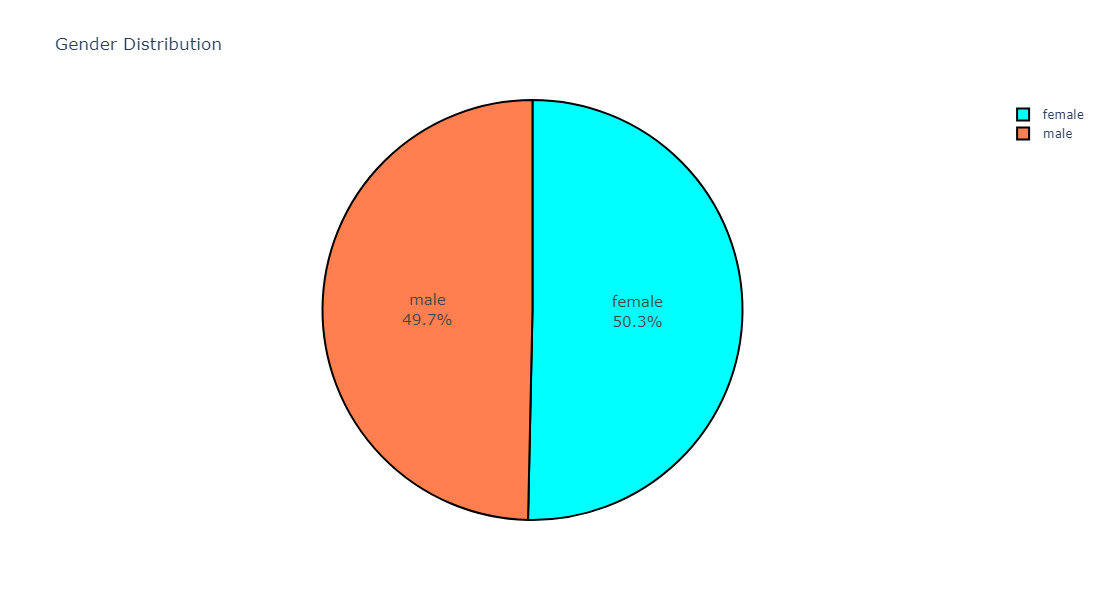

In [39]:
label = gender_count.index
count = gender_count.values
fig = px.pie(names=label, values=count, title='Gender Distribution', height=600)
fig.update_traces(hoverinfo='percent+label', textinfo='percent+label', textfont_size=15, marker=dict(colors=['cyan', 'coral'], line=dict(color='black', width=2)))
fig.show()

#### From the above pie chart we have analysed that the number of females in the data is more than the number of males

# Impact of parent education in the chlid score

In [42]:
impact_of_parent_edu = df.groupby('ParentEduc')[['MathScore', 'ReadingScore', 'WritingScore']].mean()
impact_of_parent_edu

,MathScore,ReadingScore,WritingScore
ParentEduc,,,
associate's degree,68.365586,71.124324,70.299099
bachelor's degree,70.466627,73.062020,73.331069
high school,64.435731,67.213997,65.421136
master's degree,72.336134,75.832921,76.356896
some college,66.390472,69.179708,68.501432
some high school,62.584013,65.510785,63.632409


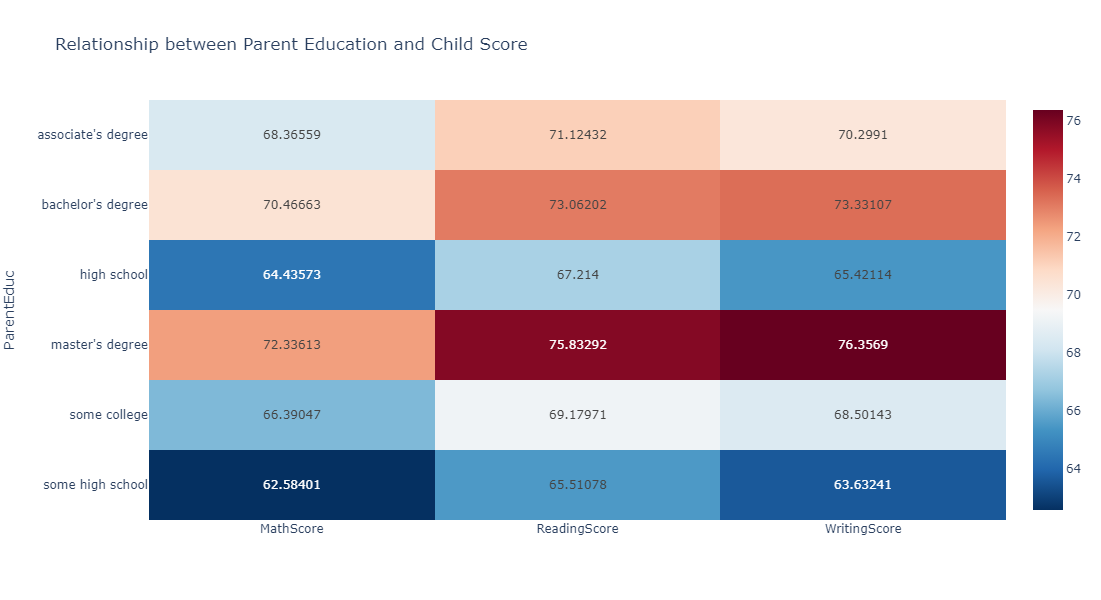

In [67]:
fig = px.imshow(impact_of_parent_edu, text_auto=True, aspect='auto', height=600, color_continuous_scale='RdBu_r', title='Relationship between Parent Education and Child Score')
fig.show()

#### From the above chart we have concluded that the education of the parent have a good impact on thier child education

# Impact of Parent Marital Status in the chlid score

In [63]:
impact_of_parent_mart_st = df.groupby('ParentMaritalStatus')[['MathScore', 'ReadingScore', 'WritingScore']].mean()
impact_of_parent_mart_st

,MathScore,ReadingScore,WritingScore
ParentMaritalStatus,,,
divorced,66.691197,69.655011,68.799146
married,66.657326,69.389575,68.420981
single,66.165704,69.157250,68.174440
widowed,67.368866,69.651438,68.563452


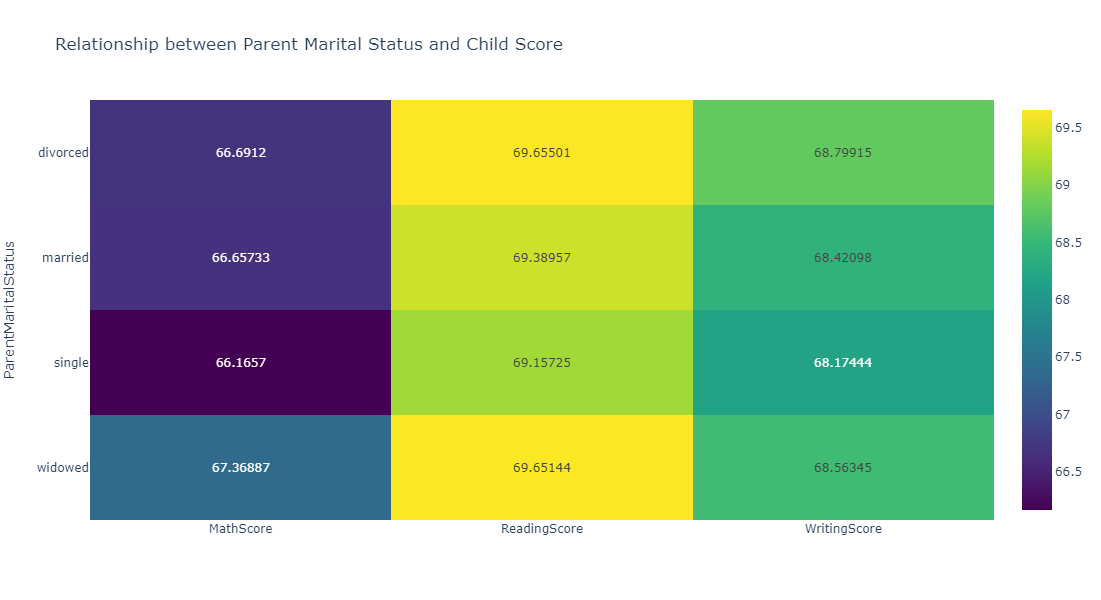

In [68]:
fig = px.imshow(impact_of_parent_mart_st, text_auto=True, aspect='auto', height=600, color_continuous_scale='Viridis', title='Relationship between Parent Marital Status and Child Score')
fig.show()

#### From the above chart we have concluded that the marital status of the parent have a negligible impact on thier child education

# Impact of Sports in student marks

In [70]:
impact_sports_marks = df.groupby('PracticeSport')[['MathScore', 'ReadingScore', 'WritingScore']].mean()
impact_sports_marks

,MathScore,ReadingScore,WritingScore
PracticeSport,,,
never,64.171079,68.337662,66.522727
regularly,67.839155,69.943019,69.604003
sometimes,66.274831,69.241307,68.072438


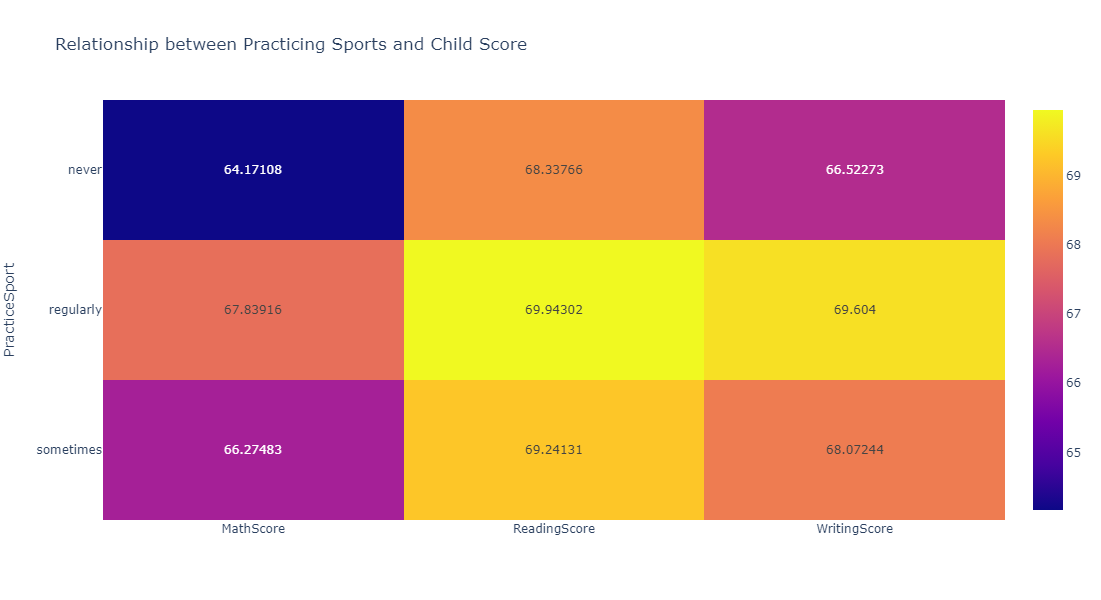

In [72]:
fig = px.imshow(impact_sports_marks, text_auto=True, aspect='auto', height=600, title='Relationship between Practicing Sports and Child Score')
fig.show()

#### From the above chart we have concluded that the Practicing of sports have a good impact on thier child education

# Detecting Outlier

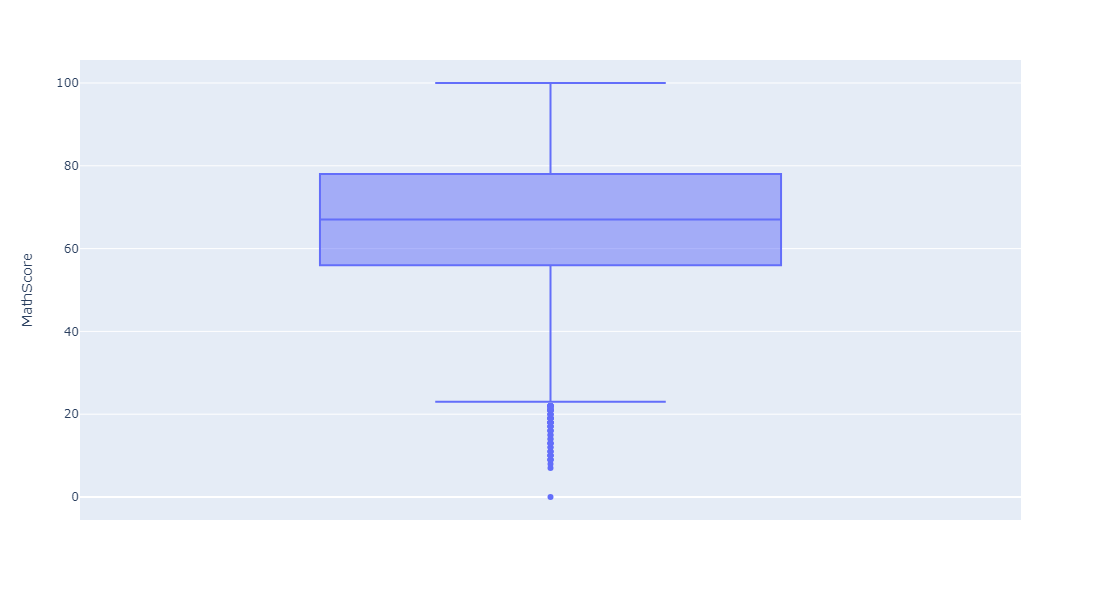

In [76]:
fig = px.box(df, y='MathScore', height = 600)
fig.show()

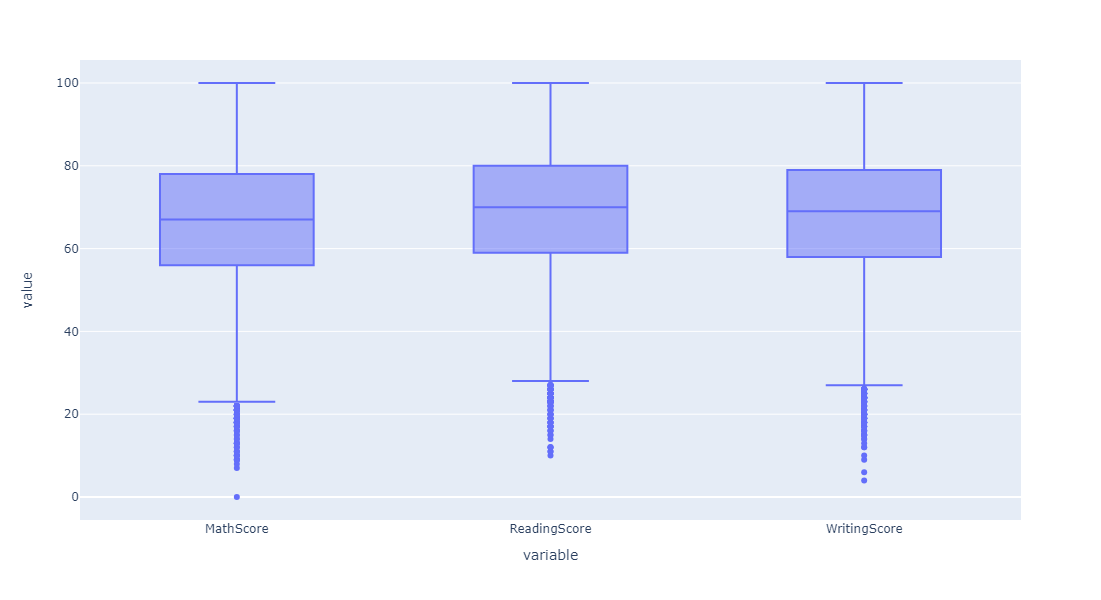

In [79]:
fig = px.box(df, y=['MathScore', 'ReadingScore', 'WritingScore'], height = 600)
fig.show()

In [80]:
df['EthnicGroup'].unique()

array([nan, 'group C', 'group B', 'group A', 'group D', 'group E'],
      dtype=object)

# Distribution of Ethnic Group

In [81]:
eth_grp = df['EthnicGroup'].value_counts()
eth_grp

EthnicGroup
group C    9212
group D    7503
group B    5826
group E    4041
group A    2219
Name: count, dtype: int64

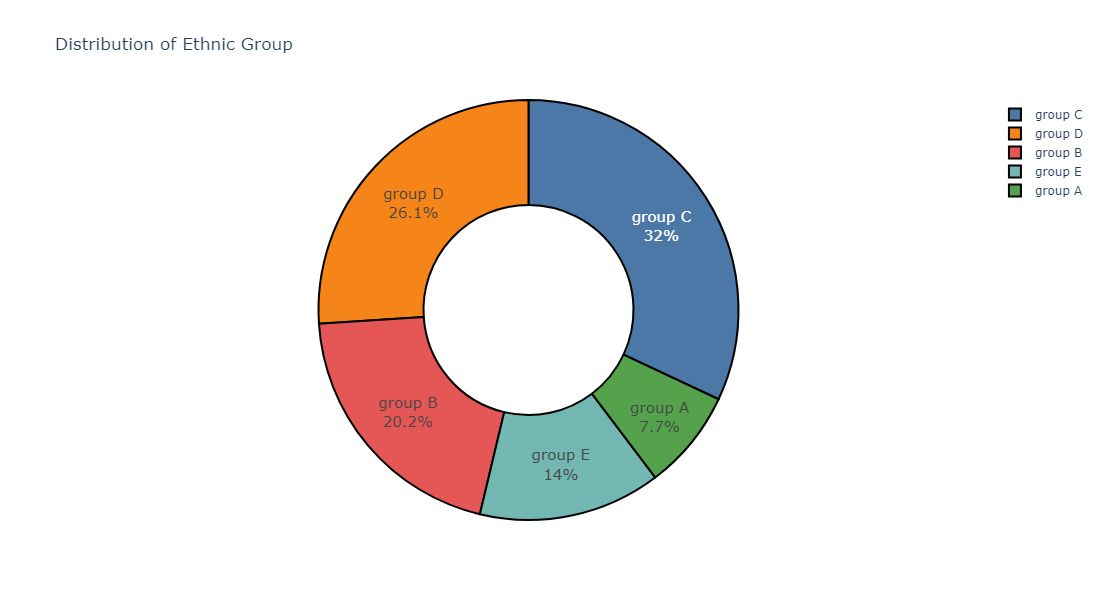

In [91]:
label = eth_grp.index
count = eth_grp.values
fig = px.pie(names=label, values=count, title='Distribution of Ethnic Group', hole=0.5, height=600, color_discrete_sequence=px.colors.qualitative.T10)
fig.update_traces(hoverinfo='percent+label', textinfo='percent+label', textfont_size=15, marker=dict(line=dict(color='black', width=2)))
fig.show()

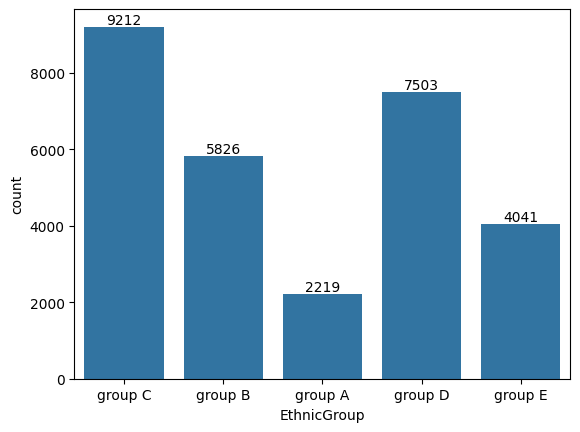

In [97]:
ax = sns.countplot(data=df, x='EthnicGroup')
ax.bar_label(ax.containers[0])
plt.show()